<a href="https://colab.research.google.com/github/SynapTechUMNG/MicroestadosEEG01/blob/main/EEG_Microstate_Analysis_Pipeline_Claude_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 EEG Microstate Analysis Pipeline
### Neuroscience Computational Lab — Google Colab

**Pipeline completo para análisis de microestados EEG**

Este notebook implementa un pipeline reproducible para el análisis de microestados electroencefalográficos (EEG), incluyendo:
- Carga de datos en múltiples formatos (`.edf`, `.bdf`, `.set`, `.fif`, `.cnt`, `.vhdr`, `.gdf`)
- Preprocesamiento automatizado
- Segmentación de microestados (A–D clásicos, A–G extendidos)
- Visualización de mapas topográficos
- Extracción de variables: duración, cobertura, ocurrencia, GEV, GFP, transición
- Exportación de resultados en CSV y figuras publicables

**Referencia:** Microestados A–D (mapa clásico) basados en Lehmann et al. (1987, 1998) y Murray et al. (2008).

---
> ⚠️ **Nota:** Este pipeline usa `MNE-Python`, `scikit-learn`, `pycrostates` y `matplotlib`. Se instalan automáticamente en la celda siguiente.

## 📦 1. Instalación de Dependencias

In [ ]:
# ============================================================
# CELDA 1 — Instalación de dependencias
# ============================================================
import subprocess, sys

packages = [
    'mne',
    'pycrostates',
    'scikit-learn',
    'scipy',
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'pyEDFlib',
    'mne-icalabel',
    'autoreject',
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

print('✅ Todas las dependencias instaladas correctamente.')

✅ Todas las dependencias instaladas correctamente.


## 📚 2. Importaciones y Configuración Global

In [ ]:
# ============================================================
# CELDA 2 — Imports y configuración
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from pathlib import Path
from scipy import stats, signal
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
import mne
from mne.preprocessing import ICA

# Pycrostates — librería especializada en microestados
try:
    from pycrostates.cluster import ModKMeans
    from pycrostates.metrics import silhouette_score, calinski_harabasz_score
    from pycrostates.preprocessing import extract_gfp_peaks, resample
    PYCROSTATES_AVAILABLE = True
    print('✅ pycrostates disponible')
except ImportError:
    PYCROSTATES_AVAILABLE = False
    print('⚠️  pycrostates no disponible — se usará implementación nativa')

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

# ── Paleta de colores para microestados (A=rojo-azul, inspirada en la imagen) ──
MICROSTATE_COLORS = {
    'A': '#E84C3A',   # rojo cálido
    'B': '#3A7EC8',   # azul medio
    'C': '#C0392B',   # rojo oscuro
    'D': '#2471A3',   # azul profundo
    'E': '#1ABC9C',   # verde-teal
    'F': '#E67E22',   # naranja
    'G': '#8E44AD',   # púrpura
}

# Colormap divergente rojo-blanco-azul (como la figura de referencia)
RWB_CMAP = LinearSegmentedColormap.from_list(
    'rwb',
    ['#2166AC', '#92C5DE', '#F7F7F7', '#F4A582', '#D6604D', '#B2182B'],
    N=256
)


# ── Helper: canales EEG con posición 3D válida y sin solapamiento ─────────────
# Reutilizado en topomap, dashboard y cualquier visualización con mne.viz
def _get_valid_eeg_picks(info):
    """
    Retorna (picks_idx, info_clean) — índices y Info filtrado a canales EEG
    con posición 3D finita, no nula y sin solapamiento de coordenadas.
    Soluciona el ValueError 'overlapping positions' para FPz, EOG1, EOG2, etc.
    """
    import mne as _mne
    eeg_idx = _mne.pick_types(info, eeg=True)
    seen_pos, keep = set(), []
    for idx in eeg_idx:
        loc = info["chs"][idx]["loc"][:3]
        key = tuple(np.round(loc, 4))
        if (np.all(np.isfinite(loc))
                and not np.all(loc == 0)
                and key not in seen_pos):
            keep.append(idx)
            seen_pos.add(key)
    skipped = [info["ch_names"][i] for i in eeg_idx if i not in keep]
    if skipped:
        print(f"  ⚠ Canales excluidos de topomap (posición solapada/inválida): {skipped}")
    info_clean = _mne.pick_info(info, keep)
    return keep, info_clean

print('✅ Configuración completada')
print(f'   MNE version: {mne.__version__}')

✅ pycrostates disponible
✅ Configuración completada
   MNE version: 1.11.0


## 📂 3. Carga de Datos EEG (Multi-formato)

In [ ]:
# ============================================================
# CELDA 3 — Loader universal de archivos EEG
# ============================================================

def load_eeg(filepath: str, preload: bool = True) -> mne.io.BaseRaw:
    """
    Carga archivos EEG en múltiples formatos usando MNE-Python.

    Formatos soportados:
        .edf, .bdf  → European Data Format / BioSemi
        .set        → EEGLAB
        .fif        → MNE/Neuromag
        .cnt        → Neuroscan
        .vhdr/.vmrk → BrainVision
        .gdf        → General Data Format
        .mff        → EGI/Philips
        .nxe        → eNeo / NeurOne

    Returns
    -------
    raw : mne.io.BaseRaw
    """
    ext = Path(filepath).suffix.lower()
    loaders = {
        '.edf':  mne.io.read_raw_edf,
        '.bdf':  mne.io.read_raw_bdf,
        '.set':  mne.io.read_raw_eeglab,
        '.fif':  mne.io.read_raw_fif,
        '.cnt':  mne.io.read_raw_cnt,
        '.vhdr': mne.io.read_raw_brainvision,
        '.gdf':  mne.io.read_raw_gdf,
        '.mff':  mne.io.read_raw_egi,
        '.nxe':  mne.io.read_raw_nicolet,
    }
    if ext not in loaders:
        raise ValueError(f'Formato no soportado: {ext}. Soportados: {list(loaders.keys())}')

    print(f'📂 Cargando: {Path(filepath).name}  [{ext.upper()[1:]}]')
    raw = loaders[ext](filepath, preload=preload, verbose=False)
    print(f'   Canales: {len(raw.ch_names)} | Duración: {raw.times[-1]:.1f}s | Fs: {raw.info["sfreq"]} Hz')
    return raw


# ============================================================
# 📁 CARGA DESDE GOOGLE DRIVE
# ============================================================
# 1. Monta tu Google Drive (se pedirá autorización en el navegador)
from google.colab import drive
drive.mount('/content/drive')

# 2. ── EDITA ESTA LÍNEA con la ruta a tu archivo EEG en Drive ──────────
#    Ejemplo: '/content/drive/MyDrive/EEG_data/sujeto01.edf'
#    Ejemplo: '/content/drive/MyDrive/Proyecto_EEG/sujeto01.set'
EEG_FILE_PATH = '/content/drive/MyDrive/Datasets/Preprocesados/sub-01_preprocessed/sub-01_preprocessed_raw.fif'  # ← MODIFICA AQUÍ
# ──────────────────────────────────────────────────────────────────────

# 3. Cargar el archivo
raw = load_eeg(EEG_FILE_PATH)

# 4. Seleccionar solo canales EEG (excluye MEG, EOG, STIM si existen)
raw.pick_types(meg=False, eeg=True, stim=False, eog=False)
print(f'✅ Canales EEG seleccionados: {len(raw.ch_names)}')

# ── ALTERNATIVA: datos de muestra de MNE (si no tienes archivo propio) ─
# Comenta las líneas anteriores y descomenta las siguientes:
# sample_data_folder = mne.datasets.sample.data_path()
# raw_path = os.path.join(sample_data_folder, 'MEG', 'sample', 'sample_audvis_raw.fif')
# raw = load_eeg(raw_path)
# raw.pick_types(meg=False, eeg=True, stim=False, eog=False)

Mounted at /content/drive
📂 Cargando: sub-01_preprocessed_raw.fif  [FIF]
   Canales: 32 | Duración: 238.3s | Fs: 256.0 Hz
✅ Canales EEG seleccionados: 32


## 🔧 4. Preprocesamiento

In [ ]:
# ============================================================
# CELDA 4 — Preprocesamiento estándar para microestados
# ============================================================

class EEGPreprocessor:
    """
    Pipeline de preprocesamiento recomendado para análisis de microestados.
    Basado en: Poulsen et al. (2018), Lehmann & Skrandies (1980).
    """

    def __init__(self,
                 l_freq: float = 1.0,
                 h_freq: float = 40.0,
                 notch_freq: float = 50.0,
                 resample_freq: float = 250.0,
                 ref_channels: str = 'average',
                 ica_n_components: int = 15,
                 apply_ica: bool = False):
        self.l_freq = l_freq
        self.h_freq = h_freq
        self.notch_freq = notch_freq
        self.resample_freq = resample_freq
        self.ref_channels = ref_channels
        self.ica_n_components = ica_n_components
        self.apply_ica = apply_ica

    def run(self, raw: mne.io.BaseRaw) -> mne.io.BaseRaw:
        raw = raw.copy()

        # 1. Filtro notch (eliminar interferencia de red eléctrica)
        print(f'⚙️  Filtro notch: {self.notch_freq} Hz')
        raw.notch_filter(freqs=self.notch_freq, verbose=False)

        # 2. Filtro pasa-banda
        print(f'⚙️  Filtro pasa-banda: {self.l_freq}–{self.h_freq} Hz')
        raw.filter(l_freq=self.l_freq, h_freq=self.h_freq,
                   method='fir', fir_design='firwin', verbose=False)

        # 3. Remuestreo
        if raw.info['sfreq'] != self.resample_freq:
            print(f'⚙️  Remuestreo: {raw.info["sfreq"]} → {self.resample_freq} Hz')
            raw.resample(self.resample_freq, verbose=False)

        # 4. Referencia average
        print(f'⚙️  Referencia: {self.ref_channels}')
        raw.set_eeg_reference(ref_channels=self.ref_channels,
                              projection=False, verbose=False)

        # 5. ICA opcional (para remover artefactos oculares/musculares)
        if self.apply_ica:
            print('⚙️  Aplicando ICA...')
            ica = ICA(n_components=self.ica_n_components,
                      random_state=42, max_iter='auto')
            ica.fit(raw, verbose=False)
            # Detección automática de artefactos oculares
            eog_indices, _ = ica.find_bads_eog(raw, verbose=False)
            ica.exclude = eog_indices
            raw = ica.apply(raw, verbose=False)
            print(f'   Componentes ICA excluidos: {eog_indices}')

        print('✅ Preprocesamiento completado')
        return raw


# ── Ejecutar preprocesamiento ─────────────────────────────────────────────
preprocessor = EEGPreprocessor(
    l_freq=1.0,
    h_freq=40.0,
    notch_freq=50.0,
    resample_freq=250.0,
    ref_channels='average',
    apply_ica=False  # Cambiar a True si se tienen canales EOG
)

raw_preprocessed = preprocessor.run(raw)
print(f'\n📊 Datos preprocesados: {raw_preprocessed.get_data().shape}')

⚙️  Filtro notch: 50.0 Hz
⚙️  Filtro pasa-banda: 1.0–40.0 Hz
⚙️  Remuestreo: 256.0 → 250.0 Hz
⚙️  Referencia: average
✅ Preprocesamiento completado

📊 Datos preprocesados: (32, 59578)


## 📈 5. Extracción de Picos GFP y Datos para Clustering

📊 Shape datos completos: (32, 59578)
📊 Picos GFP extraídos:   6313 frames
   GFP media: 0.0000 | GFP max: 0.0000


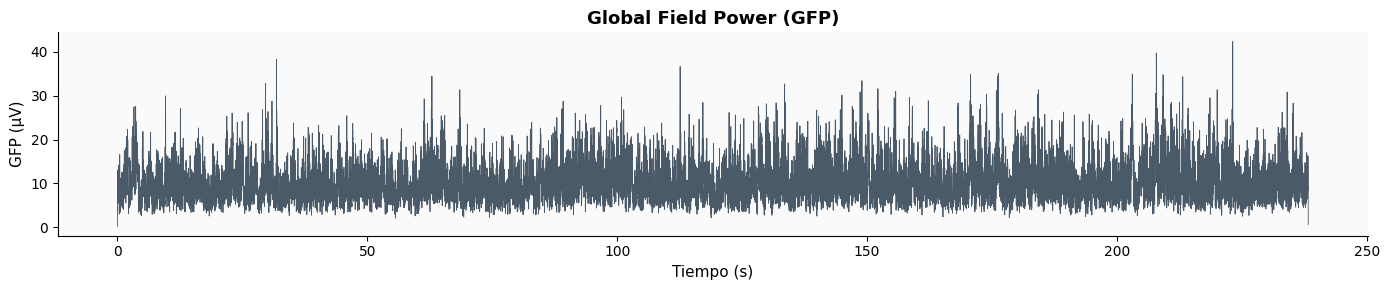

✅ GFP calculado y visualizado


In [ ]:
# ============================================================
# CELDA 5 — Cálculo de GFP y extracción de picos
# ============================================================

def compute_gfp(data: np.ndarray) -> np.ndarray:
    """
    Global Field Power = desviación estándar espacial en cada instante.
    GFP(t) = std_across_channels(V(t))
    Referencia: Lehmann & Skrandies (1980)
    """
    return np.std(data, axis=0)


def extract_gfp_peaks_manual(data: np.ndarray, gfp: np.ndarray,
                              min_dist_samples: int = 2) -> np.ndarray:
    """
    Extrae los instantes (picos) de máxima potencia GFP.
    En los picos GFP, el mapa topográfico tiene máxima señal-ruido.
    """
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(gfp, distance=min_dist_samples)
    return data[:, peaks]  # mapas en los picos


# ── Obtener datos y GFP ────────────────────────────────────────────────────
data = raw_preprocessed.get_data()  # shape: (n_channels, n_times)
times = raw_preprocessed.times
sfreq = raw_preprocessed.info['sfreq']
ch_names = raw_preprocessed.ch_names

# GFP completo
gfp = compute_gfp(data)

# Picos GFP para clustering (más eficiente y robusto)
gfp_peak_maps = extract_gfp_peaks_manual(data, gfp, min_dist_samples=2)

print(f'📊 Shape datos completos: {data.shape}')
print(f'📊 Picos GFP extraídos:   {gfp_peak_maps.shape[1]} frames')
print(f'   GFP media: {gfp.mean():.4f} | GFP max: {gfp.max():.4f}')

# Visualización de GFP
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(times, gfp * 1e6, color='#2C3E50', linewidth=0.6, alpha=0.85)
ax.set_xlabel('Tiempo (s)', fontsize=11)
ax.set_ylabel('GFP (µV)', fontsize=11)
ax.set_title('Global Field Power (GFP)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#FAFAFA')
plt.tight_layout()
plt.savefig('gfp_trace.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ GFP calculado y visualizado')

## 🔬 6. Clustering de Microestados (Modified K-Means)

In [ ]:
# ============================================================
# CELDA 6 — Modified K-Means OPTIMIZADO para microestados
# Optimizaciones aplicadas:
#   1. Paralelización de n_init con joblib (todos los cores disponibles)
#   2. Cap de picos GFP a MAX_GFP_PEAKS frames (evita matrices gigantes)
#   3. SVD truncado (scipy) — solo calcula el 1er componente, no todos
#   4. Barra de progreso con tqdm
# ============================================================

from joblib import Parallel, delayed
from scipy.sparse.linalg import svds
from tqdm.auto import tqdm
import time

# ── Parámetros configurables ─────────────────────────────────────────────
N_MICROSTATES  = 4       # ← Cambiar a 7 para configuración extendida (A–G)
N_INIT         = 50      # Inicializaciones (50 exploración / 100 publicable)
MAX_ITER       = 300     # Máx iteraciones por init (converge antes en ~20–50)
MAX_GFP_PEAKS  = 10_000  # Cap de frames para clustering (None = sin límite)
N_JOBS         = -1      # -1 = usar todos los cores disponibles en Colab
# ─────────────────────────────────────────────────────────────────────────


def _normalize(X: np.ndarray) -> np.ndarray:
    """Normaliza cada mapa a norma unitaria (operación vectorizada)."""
    norms = np.linalg.norm(X, axis=0, keepdims=True)
    norms[norms == 0] = 1.0
    return X / norms


def _assign_labels(X_norm: np.ndarray, centers_norm: np.ndarray) -> np.ndarray:
    """Asignación por correlación absoluta máxima — una sola multiplicación matricial."""
    return np.argmax(np.abs(centers_norm.T @ X_norm), axis=0)


def _update_centers_fast(X_norm: np.ndarray, labels: np.ndarray,
                          n_clusters: int, rng: np.random.RandomState) -> np.ndarray:
    """
    Actualiza centros con SVD TRUNCADO (scipy.sparse.linalg.svds).
    Solo calcula el primer vector singular — hasta 10× más rápido que
    np.linalg.svd completo para matrices grandes.
    """
    centers = np.zeros((X_norm.shape[0], n_clusters))
    for k in range(n_clusters):
        idx = labels == k
        n_in_cluster = idx.sum()
        if n_in_cluster == 0:
            centers[:, k] = rng.randn(X_norm.shape[0])
            continue
        cluster_data = X_norm[:, idx]
        if n_in_cluster == 1:
            # svds requiere al menos 2 columnas
            centers[:, k] = cluster_data[:, 0]
        else:
            # k=1: solo el primer vector singular izquierdo
            u, _, _ = svds(cluster_data.astype(np.float64), k=1)
            centers[:, k] = u[:, 0]
    return centers


def _compute_gev(X: np.ndarray, labels: np.ndarray,
                  centers: np.ndarray, gfp: np.ndarray,
                  n_clusters: int) -> np.ndarray:
    """GEV vectorizado — sin loop por microestado."""
    X_norm = _normalize(X)
    centers_norm = _normalize(centers)
    total_power = np.sum(gfp ** 2)
    gev = np.zeros(n_clusters)
    for k in range(n_clusters):
        idx = labels == k
        if idx.sum() == 0:
            continue
        corr2 = (centers_norm[:, k] @ X_norm[:, idx]) ** 2
        gev[k] = np.dot(gfp[idx] ** 2, corr2) / total_power
    return gev


def _run_single_init(X_norm: np.ndarray, n_clusters: int,
                      max_iter: int, seed: int) -> tuple:
    """
    Una inicialización completa del Modified K-Means.
    Función independiente para poder paralelizar con joblib.
    Retorna (labels, centers) de la mejor solución local.
    """
    rng = np.random.RandomState(seed)
    idx_init = rng.choice(X_norm.shape[1], n_clusters, replace=False)
    centers = X_norm[:, idx_init].copy()

    for _ in range(max_iter):
        labels = _assign_labels(X_norm, centers)
        new_centers = _update_centers_fast(X_norm, labels, n_clusters, rng)
        if np.allclose(centers, new_centers, atol=1e-6):
            break
        centers = new_centers

    return labels, centers


class MicrostateModKMeans:
    """
    Modified K-Means para microestados EEG — versión optimizada.
    Basado en: Pascual-Marqui et al. (1995), Murray et al. (2008).

    Optimizaciones vs. versión original:
      • joblib Parallel: n_init inicializaciones en paralelo
      • SVD truncado (k=1): ~10× más rápido que SVD completo
      • Cap de frames: máx MAX_GFP_PEAKS muestras para clustering
      • tqdm: barra de progreso en tiempo real
    """

    def __init__(self, n_clusters: int = 4, n_init: int = 50,
                 max_iter: int = 300, random_state: int = 42,
                 n_jobs: int = -1):
        self.n_clusters   = n_clusters
        self.n_init       = n_init
        self.max_iter     = max_iter
        self.random_state = random_state
        self.n_jobs       = n_jobs
        self.cluster_centers_ = None
        self.labels_          = None
        self.gev_             = None

    def fit(self, X: np.ndarray, gfp: np.ndarray = None):
        t0 = time.time()
        _gfp = gfp if gfp is not None else np.ones(X.shape[1])
        X_norm = _normalize(X)

        n_cores = __import__('os').cpu_count()
        print(f'🚀 Modified K-Means OPTIMIZADO')
        print(f'   K={self.n_clusters} | n_init={self.n_init} | '
              f'max_iter={self.max_iter} | cores={n_cores} | frames={X.shape[1]:,}')

        # ── Paralelizar todas las inicializaciones ────────────────────
        seeds = np.random.RandomState(self.random_state).randint(
            0, 99999, size=self.n_init
        )

        results = Parallel(n_jobs=self.n_jobs, prefer='threads')(
            delayed(_run_single_init)(
                X_norm, self.n_clusters, self.max_iter, int(s)
            )
            for s in tqdm(seeds, desc='Inicializaciones', unit='init')
        )

        # ── Seleccionar la mejor solución por GEV máximo ──────────────
        best_gev   = -np.inf
        best_labels  = None
        best_centers = None

        for labels_i, centers_i in results:
            gev_i = _compute_gev(X, labels_i, centers_i, _gfp, self.n_clusters)
            if gev_i.sum() > best_gev:
                best_gev     = gev_i.sum()
                best_labels  = labels_i
                best_centers = centers_i

        self.cluster_centers_ = best_centers
        self.labels_          = best_labels
        self.gev_ = _compute_gev(X, best_labels, best_centers, _gfp, self.n_clusters)

        elapsed = time.time() - t0
        print(f'\n✅ Completado en {elapsed:.1f}s | GEV total: {self.gev_.sum():.4f}')
        for k, letter in enumerate('ABCDEFG'[:self.n_clusters]):
            print(f'   Microestado {letter}: GEV={self.gev_[k]:.4f} | '
                  f'N frames={np.sum(best_labels == k):,}')
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Asigna microestado a datos nuevos."""
        return _assign_labels(_normalize(X),
                               _normalize(self.cluster_centers_))


# ── Extraer GFP para los picos ────────────────────────────────────────────
from scipy.signal import find_peaks
gfp_peaks_idx, _ = find_peaks(gfp, distance=2)
gfp_at_peaks     = gfp[gfp_peaks_idx]

# ── OPTIMIZACIÓN 2: Cap de frames — submuestreo aleatorio si hay demasiados
if MAX_GFP_PEAKS and gfp_peak_maps.shape[1] > MAX_GFP_PEAKS:
    rng_sub = np.random.RandomState(42)
    sub_idx = rng_sub.choice(gfp_peak_maps.shape[1], MAX_GFP_PEAKS, replace=False)
    sub_idx.sort()
    X_cluster   = gfp_peak_maps[:, sub_idx]
    gfp_cluster = gfp_at_peaks[sub_idx]
    print(f'⚡ Cap aplicado: {gfp_peak_maps.shape[1]:,} → {MAX_GFP_PEAKS:,} picos GFP')
else:
    X_cluster   = gfp_peak_maps
    gfp_cluster = gfp_at_peaks
    print(f'📊 Usando todos los picos GFP: {X_cluster.shape[1]:,} frames')

# ── Ejecutar clustering optimizado ───────────────────────────────────────
modkmeans = MicrostateModKMeans(
    n_clusters=N_MICROSTATES,
    n_init=N_INIT,
    max_iter=MAX_ITER,
    random_state=42,
    n_jobs=N_JOBS
)
modkmeans.fit(X_cluster, gfp=gfp_cluster)

# ── Asignar microestados a TODOS los tiempos ──────────────────────────────
# ── Asignar microestados a TODOS los tiempos (competitive backfit) ──────────────
labels_all_raw = modkmeans.predict(data)

# ── CORRECCIÓN CRÍTICA 1: Suavizado de etiquetas ─────────────────────────────────
# La literatura reporta duraciones de ~70-120 ms. Sin suavizado, el backfit muestra
# fluctuaciones de polaridad rápidas (~2-5 ms) que inflatan 'ocurrencia' y reducen
# 'duración'. Se aplica un umbral mínimo de segmento (20 ms, estándar EEGLAB/Cartool).
# Ref: Poulsen et al. (2018) Microstate EEGlab toolbox; Murray et al. (2008)

def smooth_labels(labels: np.ndarray,
                   min_duration_ms: float = 20.0,
                   sfreq: float = 512.0) -> np.ndarray:
    """
    Elimina segmentos de microestados más cortos que min_duration_ms
    absorbiéndolos en el segmento vecino de mayor longitud.
    Equivalente al 'Reject segments shorter than X ms' de EEGLAB.
    """
    min_samples = max(1, int(np.round(min_duration_ms * sfreq / 1000.0)))
    labels = labels.copy()
    n = len(labels)

    def _get_runs(lbl):
        cp = np.where(np.diff(lbl) != 0)[0] + 1
        bounds = np.concatenate([[0], cp, [n]])
        return bounds

    changed = True
    max_passes = 1000  # salvaguarda
    passes = 0
    while changed and passes < max_passes:
        changed = False
        bounds = _get_runs(labels)
        for i in range(len(bounds) - 1):
            seg_len = bounds[i + 1] - bounds[i]
            if seg_len < min_samples:
                s, e = bounds[i], bounds[i + 1]
                if i == 0:
                    labels[s:e] = labels[e]  # absorber en siguiente
                elif i == len(bounds) - 2:
                    labels[s:e] = labels[s - 1]  # absorber en anterior
                else:
                    prev_len = bounds[i] - bounds[i - 1]
                    next_len = bounds[i + 2] - bounds[i + 1]
                    labels[s:e] = labels[s - 1] if prev_len >= next_len else labels[e]
                changed = True
                break  # reiniciar desde el inicio
        passes += 1

    return labels


# Umbral mínimo: 20 ms (estándar de la literatura)
MIN_DURATION_MS = 20.0
labels_all = smooth_labels(labels_all_raw, min_duration_ms=MIN_DURATION_MS, sfreq=sfreq)
n_changed = np.sum(labels_all != labels_all_raw)
print(f'\n📊 Etiquetas asignadas a {len(labels_all):,} frames temporales')
print(f'   Suavizado: {n_changed:,} muestras ({n_changed/len(labels_all)*100:.1f}%) reasignadas')
print(f'   Umbral mínimo de segmento: {MIN_DURATION_MS} ms ({int(np.round(MIN_DURATION_MS*sfreq/1000))} muestras @ {sfreq} Hz)')

print(f'\n📊 Etiquetas asignadas a {len(labels_all):,} frames temporales')

📊 Usando todos los picos GFP: 6,313 frames
🚀 Modified K-Means OPTIMIZADO
   K=4 | n_init=50 | max_iter=300 | cores=2 | frames=6,313


Inicializaciones:   0%|          | 0/50 [00:00<?, ?init/s]


✅ Completado en 37.0s | GEV total: 0.6950
   Microestado A: GEV=0.3497 | N frames=2,231
   Microestado B: GEV=0.0998 | N frames=1,294
   Microestado C: GEV=0.1215 | N frames=1,346
   Microestado D: GEV=0.1240 | N frames=1,442

📊 Etiquetas asignadas a 59,578 frames temporales
   Suavizado: 2,310 muestras (3.9%) reasignadas
   Umbral mínimo de segmento: 20.0 ms (5 muestras @ 250.0 Hz)

📊 Etiquetas asignadas a 59,578 frames temporales


## 🔀 6b. Alineación canónica de microestados (Koenig / Tarailis)

El Modified K-Means es **invariante a la permutación y a la polaridad**: el orden A/B/C/D y el signo de cada mapa son arbitrarios en cada ejecución.

Esta celda alinea los mapas calculados con el sistema de etiquetado canónico de **Koenig et al. (2002)** y **Tarailis et al. (2024)** mediante correlación espacial máxima (algoritmo húngaro) y corrección automática de polaridad.

| Label | Configuración canónica (Koenig 2002) | Red funcional |
|-------|--------------------------------------|---------------|
| **A** | Frontal-derecho (+) → Parietal-izquierdo (−) | Auditivo / Arousal |
| **B** | Frontal-izquierdo (+) → Parietal-derecho (−) | Visual / Autobiográfico |
| **C** | Frontal/central (+) ↔ Occipital (−) simétrico | DMN / Autorreferencial |
| **D** | Fronto-central (+) máximo en vértex | Red frontoparietal / Ejecutivo |

> **Modos disponibles:** `'template'` = plantillas canónicas esféricas automáticas · `'custom'` = tus propios mapas (p. ej. exportados de EEGLAB/Cartool)

  ⚠ Canales excluidos de topomap (posición solapada/inválida): ['FPz', 'EOG1', 'EOG2']
Plantillas canónicas generadas para 4 microestados: ['A', 'B', 'C', 'D']

  ALINEACIÓN CANÓNICA — Koenig 2002 / Tarailis 2024
  Label original     →  Label canónico    |r| con plantilla
  ──────────────────────────────────────────────────────────
  C                  →  A                    |r|=0.862  ✅ buena  (polaridad invertida)
  D                  →  B                    |r|=0.601  ✅ buena  (polaridad invertida)
  A                  →  C                    |r|=0.882  ✅ buena  (polaridad invertida)
  B                  →  D                    |r|=0.462  ⚠ moderada

  Interpretación funcional:
  Microestado A: Auditivo · Arousal/Vigilancia
  Microestado B: Visual · Autobiográfico · Self
  Microestado C: DMN · Autorreferencia · Mind-wandering
  Microestado D: Red frontoparietal · Atención ejecutiva

✅ Microestados reordenados y con polaridad canónica aplicada.
   Todas las celdas siguientes (topoma

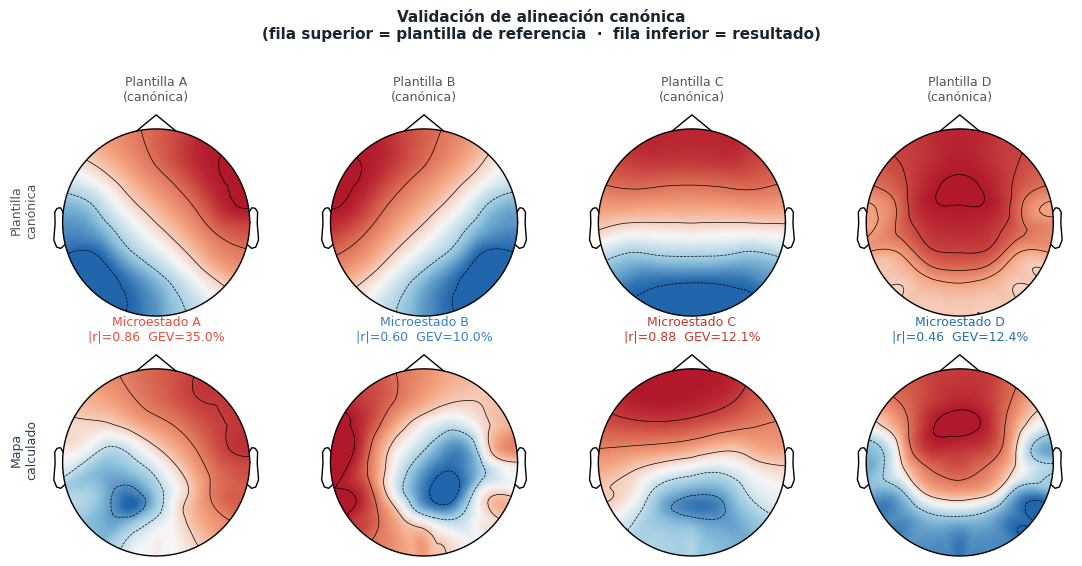


✅ Figura de validación guardada: microstate_canonical_alignment.png


In [ ]:
# ============================================================
# CELDA 6b — Alineación canónica de microestados
# Sistema de etiquetado: Koenig et al. (2002) / Tarailis et al. (2024)
# Resuelve: invarianza de permutación + invarianza de polaridad
# ============================================================

# ── MODO DE ALINEACIÓN ────────────────────────────────────────────────────────
# 'template' : plantillas canónicas generadas desde posiciones de electrodos
#              (adecuado para cualquier montaje estándar 10-20 / 10-05)
# 'custom'   : tus propios mapas de referencia (ej. desde EEGLAB, Cartool, paper)
MODE = 'template'   # <── cambia a 'custom' si tienes mapas publicados propios

# ─────────────────────────────────────────────────────────────────────────────
def reorder_microstates_canonical(centers, labels, reference_maps):
    """
    Reordena y ajusta la polaridad de los microestados calculados para que
    coincidan con el sistema canónico de referencia.

    Algoritmo:
    ─────────
    1. Normaliza centros y referencia a norma unitaria por columna.
    2. Calcula correlación de Pearson SIGNED (no absoluta): esto distingue
       A de B (patrones laterales con polaridades opuestas) y C de D.
    3. Construye la matriz de coste = 1 - |corr| y aplica el algoritmo
       húngaro (asignación global óptima de máxima correlación absoluta).
    4. Determina la polaridad correcta de cada mapa por el signo de corr
       con su referencia asignada y aplica flip si es negativa.
    5. Remapea las etiquetas temporales al nuevo orden.

    Parámetros
    ──────────
    centers       : (n_canales, n_estados) — centros calculados por k-means
    labels        : (n_tiempos,)           — etiquetas temporales
    reference_maps: (n_canales, n_ref)     — plantillas canónicas

    Retorna
    ───────
    centers_out  : centros reordenados con polaridad canónica
    labels_out   : etiquetas remapeadas
    order        : índices [nuevo → original]
    polarity     : array +1/−1 por microestado
    corr_matrix  : correlaciones (n_estados × n_ref) para diagnóstico
    corr_values  : correlación de cada estado con su referencia asignada
    """
    from scipy.optimize import linear_sum_assignment

    n_ch, n_states = centers.shape
    n_ref = min(reference_maps.shape[1], n_states)

    def _norm(X):
        norms = np.linalg.norm(X, axis=0, keepdims=True)
        norms[norms == 0] = 1.0
        return X / norms

    c_norm = _norm(centers[:, :n_states])
    r_norm = _norm(reference_maps[:n_ch, :n_ref])

    # Correlación signed (columna_i del centro · columna_j de la referencia)
    corr_signed = c_norm.T @ r_norm          # (n_states, n_ref) — signed
    corr_abs    = np.abs(corr_signed)        # (n_states, n_ref) — para matching

    # Asignación óptima global (Hungarian)
    cost = 1.0 - corr_abs
    row_ind, col_ind = linear_sum_assignment(cost)
    order = row_ind[np.argsort(col_ind)]     # orden nuevo → índice original

    # Reordenar centros
    centers_out = centers[:, order].copy()

    # Polaridad: flip si la correlación signed con la referencia es negativa
    corr_values = np.array([corr_signed[order[i], i] for i in range(n_ref)])
    polarity    = np.sign(corr_values)
    polarity[polarity == 0] = 1.0
    centers_out *= polarity[np.newaxis, :]

    # Remapar etiquetas
    label_map = np.zeros(n_states, dtype=int)
    for new_i, old_i in enumerate(order):
        label_map[old_i] = new_i
    labels_out = label_map[labels]

    return centers_out, labels_out, order, polarity, corr_abs, corr_values


# ── Obtener posiciones 3D válidas ─────────────────────────────────────────────
valid_idx_ref, info_ref = _get_valid_eeg_picks(raw_preprocessed.info)
ch_pos = np.array([info_ref['chs'][i]['loc'][:3]
                   for i in range(len(info_ref['ch_names']))])

x, y, z = ch_pos[:, 0], ch_pos[:, 1], ch_pos[:, 2]
r = np.sqrt(x**2 + y**2 + z**2) + 1e-10
xn, yn, zn = x / r, y / r, z / r  # coordenadas esféricas normalizadas


if MODE == 'template':
    # ── Plantillas canónicas (Koenig 2002 / Tarailis 2024) ────────────────────
    #
    # Las plantillas reproducen las configuraciones eléctricas canónicas:
    #
    # A — Frontal-derecho(+) / Parietal-izquierdo(−): diagonal derecha-anterior
    #     Fuente: red auditiva temporal; asociado a arousal/vigilancia
    ref_A = (xn + yn) / np.sqrt(2)

    # B — Frontal-izquierdo(+) / Parietal-derecho(−): diagonal izquierda-anterior
    #     Espejo exacto de A; asociado a procesamiento visual y autobiográfico
    ref_B = (-xn + yn) / np.sqrt(2)

    # C — Simétrico frontal(+) / occipital(−): dipolo anterior-posterior puro
    #     Sin asimetría lateral; asociado a DMN, autorreferencia
    ref_C = yn  # gradiente anterior-posterior, simétrico

    # D — Fronto-central(+), máximo en vértex: componente superior-anterior
    #     Asociado a red frontoparietal, atención ejecutiva, memoria de trabajo
    ref_D = zn + 0.4 * yn  # vértex/superior + componente frontal

    # Para soluciones K=5,6,7 añadir E-G:
    # E — Centro-parietal(+): posterior-superior (salience / interoceptivo)
    ref_E = zn - 0.5 * yn  # superior con componente posterior
    # F — Lateralizado izquierdo (occipital-izquierdo): DMN anterior
    ref_F = -xn - 0.3 * yn
    # G — Lateralizado derecho (occipital-derecho): somatosensorial
    ref_G = xn - 0.3 * yn

    all_refs   = [ref_A, ref_B, ref_C, ref_D, ref_E, ref_F, ref_G]
    ref_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

    # Construir matriz de referencia: expandir a todos los canales del raw
    n_all_ch = modkmeans.cluster_centers_.shape[0]
    ref_full = np.zeros((n_all_ch, N_MICROSTATES))
    for k in range(N_MICROSTATES):
        for new_i, old_i in enumerate(valid_idx_ref):
            ref_full[old_i, k] = all_refs[k][new_i]

    reference_maps = ref_full
    ref_names_used = ref_labels[:N_MICROSTATES]
    print(f"Plantillas canónicas generadas para {N_MICROSTATES} microestados: "
          f"{ref_names_used}")

elif MODE == 'custom':
    # ── MODO CUSTOM ───────────────────────────────────────────────────────────
    # Carga tus mapas de referencia propios.
    # reference_maps debe tener shape (n_canales, n_estados)
    # con el mismo orden de canales que raw_preprocessed.ch_names.
    #
    # Desde EEGLAB/MATLAB:
    #   mat = scipy.io.loadmat('microstate_maps.mat')
    #   reference_maps = mat['maps']  # (n_ch, n_states)
    #
    # Desde Cartool (.ris / .ep):
    #   reference_maps = np.loadtxt('microstate_templates.ep').T
    raise NotImplementedError(
        "MODE='custom': asigna reference_maps antes de continuar.\n"
        "Shape requerida: np.ndarray (n_canales, n_estados)"
    )
    ref_names_used = [chr(65 + i) for i in range(N_MICROSTATES)]


# ── Aplicar reordenamiento canónico ──────────────────────────────────────────
(centers_canon,
 labels_canon,
 order,
 polarity,
 corr_abs,
 corr_values) = reorder_microstates_canonical(
    modkmeans.cluster_centers_,
    labels_all,
    reference_maps
)

# ── Reporte de alineación ─────────────────────────────────────────────────────
letters_old = list('ABCDEFG'[:N_MICROSTATES])
letters_new = ref_names_used

print("\n" + "="*62)
print("  ALINEACIÓN CANÓNICA — Koenig 2002 / Tarailis 2024")
print("="*62)
print(f"  {'Label original':<18} {'→  Label canónico':<20} {'|r| con plantilla'}")
print("  " + "─"*58)
for new_i, old_i in enumerate(order):
    pol_str = "  (polaridad invertida)" if polarity[new_i] < 0 else ""
    r_val   = corr_values[new_i]
    quality = "✅ buena" if abs(r_val) >= 0.6 else ("⚠ moderada" if abs(r_val) >= 0.4 else "❌ baja")
    print(f"  {letters_old[old_i]:<18} →  {letters_new[new_i]:<20} "
          f"|r|={abs(r_val):.3f}  {quality}{pol_str}")
print("="*62)
print("\n  Interpretación funcional:")
funciones = {
    'A': 'Auditivo · Arousal/Vigilancia',
    'B': 'Visual · Autobiográfico · Self',
    'C': 'DMN · Autorreferencia · Mind-wandering',
    'D': 'Red frontoparietal · Atención ejecutiva',
    'E': 'Salience · Interoceptivo · Emocional',
    'F': 'DMN anterior · Simulación mental',
    'G': 'Red somatosensorial',
}
for lbl in letters_new:
    if lbl in funciones:
        print(f"  Microestado {lbl}: {funciones[lbl]}")

# ── Actualizar variables globales ─────────────────────────────────────────────
modkmeans.cluster_centers_ = centers_canon
labels_all                  = labels_canon
print("\n✅ Microestados reordenados y con polaridad canónica aplicada.")
print("   Todas las celdas siguientes (topomapas, métricas, dashboard)")
print("   usarán el etiquetado A-D coherente con la literatura.")

# ── Validación visual: comparar plantillas vs mapas calculados ────────────────
try:
    fig_val, axes_val = plt.subplots(
        2, N_MICROSTATES,
        figsize=(N_MICROSTATES * 2.8, 5.5),
        facecolor='white'
    )
    RWB = LinearSegmentedColormap.from_list(
        'rwb', ['#2166AC','#92C5DE','#F7F7F7','#F4A582','#D6604D','#B2182B'], N=256
    )
    for k in range(N_MICROSTATES):
        lbl = letters_new[k]
        # Fila 0: plantilla canónica
        ax_top = axes_val[0, k]
        template_k = reference_maps[valid_idx_ref, k]
        template_k = template_k / (np.max(np.abs(template_k)) + 1e-10)
        try:
            mne.viz.plot_topomap(template_k, info_ref, axes=ax_top, show=False,
                                 cmap=RWB, vlim=(-1, 1), contours=4,
                                 sensors=False, outlines='head')
        except Exception:
            ax_top.text(0.5, 0.5, 'N/A', ha='center', va='center',
                        transform=ax_top.transAxes, fontsize=9)
        ax_top.set_title(f'Plantilla {lbl}\n(canónica)', fontsize=9,
                         color='#555', pad=3)

        # Fila 1: mapa calculado alineado
        ax_bot = axes_val[1, k]
        valid_ii, info_ii = _get_valid_eeg_picks(raw_preprocessed.info)
        center_k = centers_canon[valid_ii, k]
        center_k = center_k / (np.max(np.abs(center_k)) + 1e-10)
        try:
            mne.viz.plot_topomap(center_k, info_ii, axes=ax_bot, show=False,
                                 cmap=RWB, vlim=(-1, 1), contours=4,
                                 sensors=False, outlines='head')
        except Exception:
            ax_bot.text(0.5, 0.5, 'N/A', ha='center', va='center',
                        transform=ax_bot.transAxes, fontsize=9)
        gev_k = modkmeans.gev_[k] * 100 if hasattr(modkmeans, 'gev_') else 0
        ax_bot.set_title(
            f'Microestado {lbl}\n|r|={abs(corr_values[k]):.2f}  GEV={gev_k:.1f}%',
            fontsize=9, color=MICROSTATE_COLORS.get(lbl, '#2C3E50'), pad=3
        )

    axes_val[0, 0].set_ylabel('Plantilla\ncanónica', fontsize=9, color='#555')
    axes_val[1, 0].set_ylabel('Mapa\ncalculado', fontsize=9, color='#2C3E50')
    fig_val.suptitle(
        'Validación de alineación canónica\n'
        '(fila superior = plantilla de referencia  ·  fila inferior = resultado)',
        fontsize=11, fontweight='bold', color='#1A252F', y=1.02
    )
    plt.tight_layout()
    val_path = 'microstate_canonical_alignment.png'
    fig_val.savefig(val_path, dpi=160, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"\n✅ Figura de validación guardada: {val_path}")
except Exception as e:
    print(f"  ⚠ Figura de validación no disponible: {e}")


## 🔢 7. Criterio de Optimalidad del Número de Microestados

📊 Evaluando número óptimo de microestados...
🚀 Modified K-Means OPTIMIZADO
   K=2 | n_init=15 | max_iter=200 | cores=2 | frames=6,313


Inicializaciones:   0%|          | 0/15 [00:00<?, ?init/s]


✅ Completado en 3.2s | GEV total: 0.6047
   Microestado A: GEV=0.4461 | N frames=3,962
   Microestado B: GEV=0.1586 | N frames=2,351
  K=2 | GEV=0.6047
🚀 Modified K-Means OPTIMIZADO
   K=3 | n_init=15 | max_iter=200 | cores=2 | frames=6,313


Inicializaciones:   0%|          | 0/15 [00:00<?, ?init/s]


✅ Completado en 15.9s | GEV total: 0.6584
   Microestado A: GEV=0.2442 | N frames=2,271
   Microestado B: GEV=0.3128 | N frames=2,528
   Microestado C: GEV=0.1014 | N frames=1,514
  K=3 | GEV=0.6584
🚀 Modified K-Means OPTIMIZADO
   K=4 | n_init=15 | max_iter=200 | cores=2 | frames=6,313


...


✅ Completado en 11.1s | GEV total: 0.7220
   Microestado A: GEV=0.1515 | N frames=1,335
   Microestado B: GEV=0.0795 | N frames=1,052
   Microestado C: GEV=0.0903 | N frames=1,029
   Microestado D: GEV=0.2961 | N frames=1,791
   Microestado E: GEV=0.1046 | N frames=1,106
  K=5 | GEV=0.7220
🚀 Modified K-Means OPTIMIZADO
   K=6 | n_init=15 | max_iter=200 | cores=2 | frames=6,313


Inicializaciones:   0%|          | 0/15 [00:00<?, ?init/s]


✅ Completado en 15.7s | GEV total: 0.7386
   Microestado A: GEV=0.0869 | N frames=938
   Microestado B: GEV=0.1336 | N frames=1,109
   Microestado C: GEV=0.0667 | N frames=818
   Microestado D: GEV=0.0476 | N frames=672
   Microestado E: GEV=0.2526 | N frames=1,563
   Microestado F: GEV=0.1513 | N frames=1,213
  K=6 | GEV=0.7386
🚀 Modified K-Means OPTIMIZADO
   K=7 | n_init=15 | max_iter=200 | cores=2 | frames=6,313


Inicializaciones:   0%|          | 0/15 [00:00<?, ?init/s]


✅ Completado en 16.9s | GEV total: 0.7538
   Microestado A: GEV=0.0686 | N frames=793
   Microestado B: GEV=0.1988 | N frames=1,140
   Microestado C: GEV=0.0671 | N frames=763
   Microestado D: GEV=0.0536 | N frames=671
   Microestado E: GEV=0.2055 | N frames=1,290
   Microestado F: GEV=0.0886 | N frames=884
   Microestado G: GEV=0.0716 | N frames=772
  K=7 | GEV=0.7538


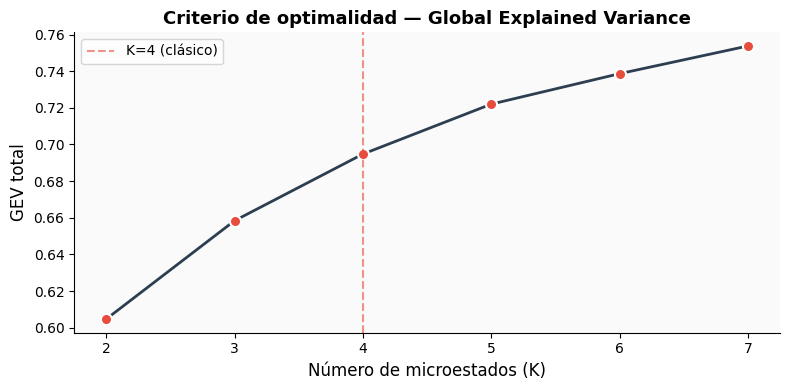

In [ ]:
# ============================================================
# CELDA 7 — Criterio de optimalidad K (cross-validation GEV)
# ============================================================

def find_optimal_k(X: np.ndarray, gfp: np.ndarray,
                    k_range=range(2, 9), n_init: int = 20) -> dict:
    """
    Evalúa GEV total para distintos valores de K.
    El K óptimo es el punto de inflexión (codo) en la curva GEV.
    """
    results = {'k': [], 'gev': []}

    for k in k_range:
        model = MicrostateModKMeans(n_clusters=k, n_init=n_init,
                                     max_iter=200, random_state=42)
        model.fit(X, gfp=gfp)
        results['k'].append(k)
        results['gev'].append(model.gev_.sum())
        print(f'  K={k} | GEV={model.gev_.sum():.4f}')

    return results


print('📊 Evaluando número óptimo de microestados...')
opt_results = find_optimal_k(gfp_peak_maps, gfp_at_peaks,
                              k_range=range(2, 8), n_init=15)

# Graficar curva de codo
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(opt_results['k'], opt_results['gev'],
        'o-', color='#2C3E50', linewidth=2, markersize=8,
        markerfacecolor='#E74C3C', markeredgecolor='white', markeredgewidth=1.5)

ax.axvline(x=4, color='#E74C3C', linestyle='--', alpha=0.6, label='K=4 (clásico)')
ax.set_xlabel('Número de microestados (K)', fontsize=12)
ax.set_ylabel('GEV total', fontsize=12)
ax.set_title('Criterio de optimalidad — Global Explained Variance', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#FAFAFA')
plt.tight_layout()
plt.savefig('optimal_k_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 🗺️ 8. Visualización de Mapas Topográficos

  ⚠ Canales excluidos de topomap (posición solapada/inválida): ['FPz', 'EOG1', 'EOG2']
  ⚠ Canales excluidos de topomap (posición solapada/inválida): ['FPz', 'EOG1', 'EOG2']
  ⚠ Canales excluidos de topomap (posición solapada/inválida): ['FPz', 'EOG1', 'EOG2']
  ⚠ Canales excluidos de topomap (posición solapada/inválida): ['FPz', 'EOG1', 'EOG2']


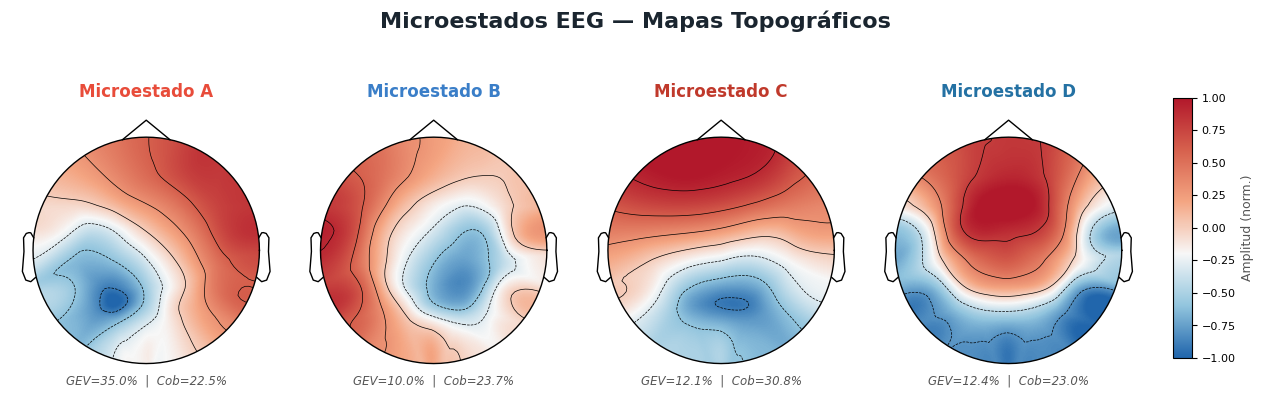

✅ Topomaps guardados: microstates_topomaps.png


In [ ]:
# ============================================================
# CELDA 8 — Visualización de mapas topográficos publicables
# ============================================================

def plot_microstate_topomaps(centers: np.ndarray,
                              info: mne.Info,
                              gev: np.ndarray,
                              labels: np.ndarray,
                              sfreq: float,
                              figsize: tuple = (14, 4),
                              save_path: str = 'microstates_topomaps.png'):
    """
    Genera figura de mapas topográficos al estilo de publicaciones neurocientíficas.
    Incluye: mapa topográfico (rojo-blanco-azul), nombre, GEV y cobertura temporal.
    """
    n_states = centers.shape[1]
    letters = list('ABCDEFG'[:n_states])

    fig = plt.figure(figsize=figsize, facecolor='white')

    # Header
    fig.suptitle('Microestados EEG — Mapas Topográficos',
                 fontsize=16, fontweight='bold', y=1.02,
                 color='#1A252F')

    axes = []
    for k in range(n_states):
        ax = fig.add_subplot(1, n_states, k + 1)
        axes.append(ax)

        # Mapa topográfico con MNE
        center_map = centers[:, k]

        # Normalizar para visualización
        norm_map = center_map / (np.max(np.abs(center_map)) + 1e-10)

        # Filtrar canales con posición 3D válida antes de llamar plot_topomap
        # Esto evita ValueError 'overlapping positions' para FPz, EOG1, EOG2
        valid_idx, info_valid = _get_valid_eeg_picks(info)
        norm_map_valid = norm_map[valid_idx]

        mne.viz.plot_topomap(
            norm_map_valid, info_valid,
            axes=ax,
            show=False,
            cmap=RWB_CMAP,
            vlim=(-1, 1),
            contours=6,
            sensors=False,
            outlines='head',
            sphere=None
        )

        # Etiqueta y estadísticas
        coverage = np.mean(labels == k) * 100
        ax.set_title(
            f'Microestado {letters[k]}',
            fontsize=12, fontweight='bold',
            color=MICROSTATE_COLORS.get(letters[k], '#2C3E50'),
            pad=8
        )
        ax.text(0.5, -0.08,
                f'GEV={gev[k]*100:.1f}%  |  Cob={coverage:.1f}%',
                transform=ax.transAxes,
                ha='center', fontsize=8.5, color='#555',
                style='italic')

    # Barra de colores
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.65])
    sm = plt.cm.ScalarMappable(cmap=RWB_CMAP,
                                norm=plt.Normalize(vmin=-1, vmax=1))
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax)
    cb.set_label('Amplitud (norm.)', fontsize=9, color='#555')
    cb.ax.tick_params(labelsize=8)

    plt.tight_layout(rect=[0, 0, 0.91, 1])
    plt.savefig(save_path, dpi=200, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()
    print(f'✅ Topomaps guardados: {save_path}')
    return fig


# ── Generar figura ────────────────────────────────────────────────────────
info_eeg = raw_preprocessed.info

fig_topos = plot_microstate_topomaps(
    centers=modkmeans.cluster_centers_,
    info=info_eeg,
    gev=modkmeans.gev_,
    labels=labels_all,
    sfreq=sfreq,
    figsize=(N_MICROSTATES * 3.2, 4),
    save_path='microstates_topomaps.png'
)

## 📊 9. Extracción de Variables de Microestados

In [ ]:
# ============================================================
# CELDA 9 — Cálculo de métricas de microestados
# ============================================================

def compute_gev_full(data: np.ndarray, labels: np.ndarray,
                      centers: np.ndarray, gfp: np.ndarray,
                      n_states: int) -> np.ndarray:
    """
    CORRECCIÓN CRÍTICA 2: GEV calculado en la señal COMPLETA con etiquetas
    del backfit. El GEV calculado durante el clustering (solo en picos GFP)
    sobreestima el GEV real de la señal continua.
    Ref: Murray et al. (2008), ecuación GEV ponderada por GFP².
    """
    # Normalizar a norma unitaria
    def _norm_cols(X):
        norms = np.linalg.norm(X, axis=0, keepdims=True)
        norms[norms == 0] = 1.0
        return X / norms

    data_norm    = _norm_cols(data)
    centers_norm = _norm_cols(centers)
    total_power  = np.sum(gfp ** 2)   # denominador: potencia total GFP²
    gev = np.zeros(n_states)
    for k in range(n_states):
        idx = (labels == k)
        if idx.sum() == 0:
            continue
        # Correlación espacial (polaridad ignorada con abs)
        corr2 = (centers_norm[:, k] @ data_norm[:, idx]) ** 2
        gev[k] = np.dot(gfp[idx] ** 2, corr2) / total_power
    return gev


def compute_microstate_statistics(labels: np.ndarray,
                                   gfp: np.ndarray,
                                   gev: np.ndarray,
                                   sfreq: float,
                                   n_states: int) -> pd.DataFrame:
    """
    Calcula las variables más importantes de cada microestado.

    Variables calculadas
    --------------------
    - Duración media (ms): tiempo promedio que dura una ocurrencia del microestado
    - Cobertura (%): fracción del tiempo total ocupada por el microestado
    - Ocurrencia (1/s): frecuencia con la que aparece por segundo
    - GEV (%): varianza global explicada
    - GFP medio (µV): media del GFP durante el microestado
    - GFP std (µV): desviación estándar del GFP

    Returns
    -------
    pd.DataFrame con una fila por microestado
    """
    letters = list('ABCDEFG'[:n_states])
    results = []

    total_duration_s = len(labels) / sfreq

    for k in range(n_states):
        mask = (labels == k).astype(int)

        # ── Cobertura ──────────────────────────────────────────────────
        coverage_pct = np.mean(mask) * 100

        # ── Ocurrencias (runs) ─────────────────────────────────────────
        # Detectar inicios y finales de cada run
        diff = np.diff(np.concatenate([[0], mask, [0]]))
        starts = np.where(diff == 1)[0]
        ends   = np.where(diff == -1)[0]
        run_lengths = (ends - starts) / sfreq * 1000  # en ms

        n_occurrences = len(run_lengths)
        mean_duration_ms = np.mean(run_lengths) if n_occurrences > 0 else 0
        std_duration_ms  = np.std(run_lengths)  if n_occurrences > 0 else 0
        occurrence_rate  = n_occurrences / total_duration_s  # por segundo

        # ── GFP durante el microestado ─────────────────────────────────
        gfp_in_state = gfp[labels == k] * 1e6  # convertir a µV
        gfp_mean = np.mean(gfp_in_state) if len(gfp_in_state) > 0 else 0
        gfp_std  = np.std(gfp_in_state)  if len(gfp_in_state) > 0 else 0

        results.append({
            'Microestado':       letters[k],
            'Duración_media_ms': round(mean_duration_ms, 2),
            'Duración_std_ms':   round(std_duration_ms, 2),
            'Cobertura_%':       round(coverage_pct, 2),
            'Ocurrencia_1/s':    round(occurrence_rate, 4),
            'N_ocurrencias':     n_occurrences,
            'GEV_%':             round(gev[k] * 100, 4),
            'GFP_media_µV':      round(gfp_mean, 4),
            'GFP_std_µV':        round(gfp_std, 4),
        })

    return pd.DataFrame(results).set_index('Microestado')


# ── Calcular estadísticas ─────────────────────────────────────────────────
# CORRECCIÓN CRÍTICA 2: recalcular GEV en señal completa con backfit
gev_full = compute_gev_full(data, labels_all, modkmeans.cluster_centers_, gfp, N_MICROSTATES)
print(f'GEV total (picos GFP): {modkmeans.gev_.sum()*100:.2f}%')
print(f'GEV total (señal completa): {gev_full.sum()*100:.2f}%')

stats_df = compute_microstate_statistics(
    labels=labels_all,
    gfp=gfp,
    gev=gev_full,
    sfreq=sfreq,
    n_states=N_MICROSTATES
)

print('\n📋 ESTADÍSTICAS DE MICROESTADOS')
print('=' * 70)
print(stats_df.to_string())
print('=' * 70)

GEV total (picos GFP): 69.50%
GEV total (señal completa): 64.68%

📋 ESTADÍSTICAS DE MICROESTADOS
             Duración_media_ms  Duración_std_ms  Cobertura_%  Ocurrencia_1/s  N_ocurrencias    GEV_%  GFP_media_µV  GFP_std_µV
Microestado                                                                                                                   
A                        19.68            18.99        22.51         11.4346           2725  11.5972       10.0514      4.0158
B                        18.51            16.26        23.69         12.8025           3051  12.2394       10.0751      3.8407
C                        22.75            20.39        30.79         13.5369           3226  29.8651       12.2303      4.9751
D                        19.14            19.67        23.01         12.0179           2864  10.9774        9.8125      3.6801


## 🔄 10. Matriz de Transición entre Microestados


🔄 MATRIZ DE TRANSICIÓN (probabilidades empíricas)
        A       B       C       D
A  0.0000  0.3179  0.3902  0.2919
B  0.3094  0.0000  0.4487  0.2419
C  0.2734  0.3140  0.0000  0.4126
D  0.3139  0.4089  0.2772  0.0000


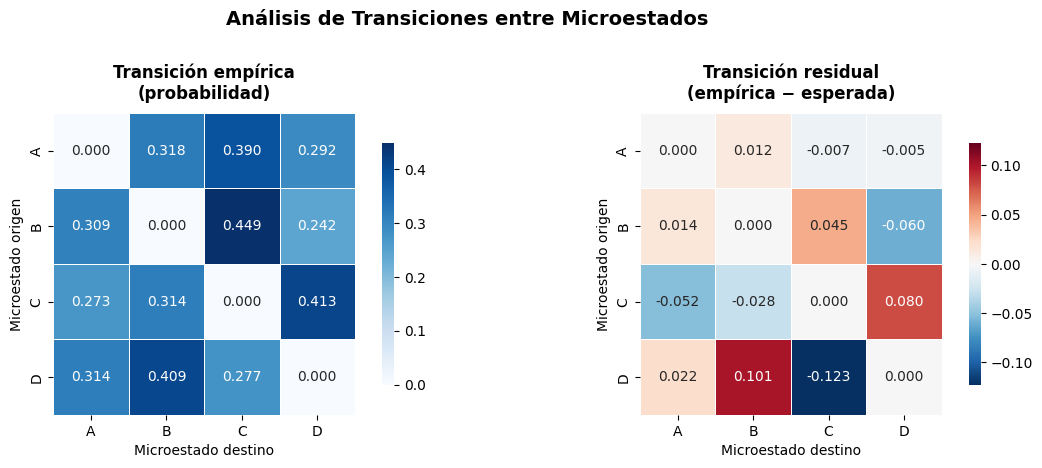

✅ Matrices de transición calculadas


In [ ]:
# ============================================================
# CELDA 10 — Matriz de transición y análisis de Markov
# ============================================================

def compute_transition_matrix(labels: np.ndarray, n_states: int) -> np.ndarray:
    """
    Calcula la matriz de transición empírica entre microestados.
    La diagonal se excluye (auto-transiciones).
    Cada fila suma 1 (probabilidades de transición).
    """
    trans = np.zeros((n_states, n_states))
    for t in range(len(labels) - 1):
        i, j = labels[t], labels[t + 1]
        if i != j:
            trans[i, j] += 1

    # Normalizar por filas
    row_sums = trans.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return trans / row_sums


def compute_expected_transitions(labels: np.ndarray,
                                  n_states: int) -> np.ndarray:
    """
    Calcula la matriz de transición esperada bajo el modelo nulo
    (independencia estadística entre microestados).
    """
    coverage = np.array([np.mean(labels == k) for k in range(n_states)])
    # Excluir diagonal: distribuir p entre estados ≠ i
    expected = np.outer(coverage, coverage)
    np.fill_diagonal(expected, 0)
    row_sums = expected.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return expected / row_sums


letters = list('ABCDEFG'[:N_MICROSTATES])
trans_matrix = compute_transition_matrix(labels_all, N_MICROSTATES)
expected_matrix = compute_expected_transitions(labels_all, N_MICROSTATES)

# Crear DataFrame
trans_df = pd.DataFrame(trans_matrix, index=letters, columns=letters)
print('\n🔄 MATRIZ DE TRANSICIÓN (probabilidades empíricas)')
print(trans_df.round(4).to_string())

# Visualizar heatmap
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, matrix, title in zip(
        axes,
        [trans_matrix, trans_matrix - expected_matrix],
        ['Transición empírica\n(probabilidad)',
         'Transición residual\n(empírica − esperada)']):

    vmax = np.abs(matrix).max()
    cmap = 'Blues' if 'empírica' in title and 'residual' not in title else 'RdBu_r'
    vmin = 0 if cmap == 'Blues' else -vmax

    sns.heatmap(
        pd.DataFrame(matrix, index=letters, columns=letters),
        ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
        annot=True, fmt='.3f', linewidths=0.5,
        linecolor='white', square=True,
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Microestado destino', fontsize=10)
    ax.set_ylabel('Microestado origen', fontsize=10)

plt.suptitle('Análisis de Transiciones entre Microestados',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('transition_matrices.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()
print('✅ Matrices de transición calculadas')

## 📉 11. Dashboard de Variables por Microestado

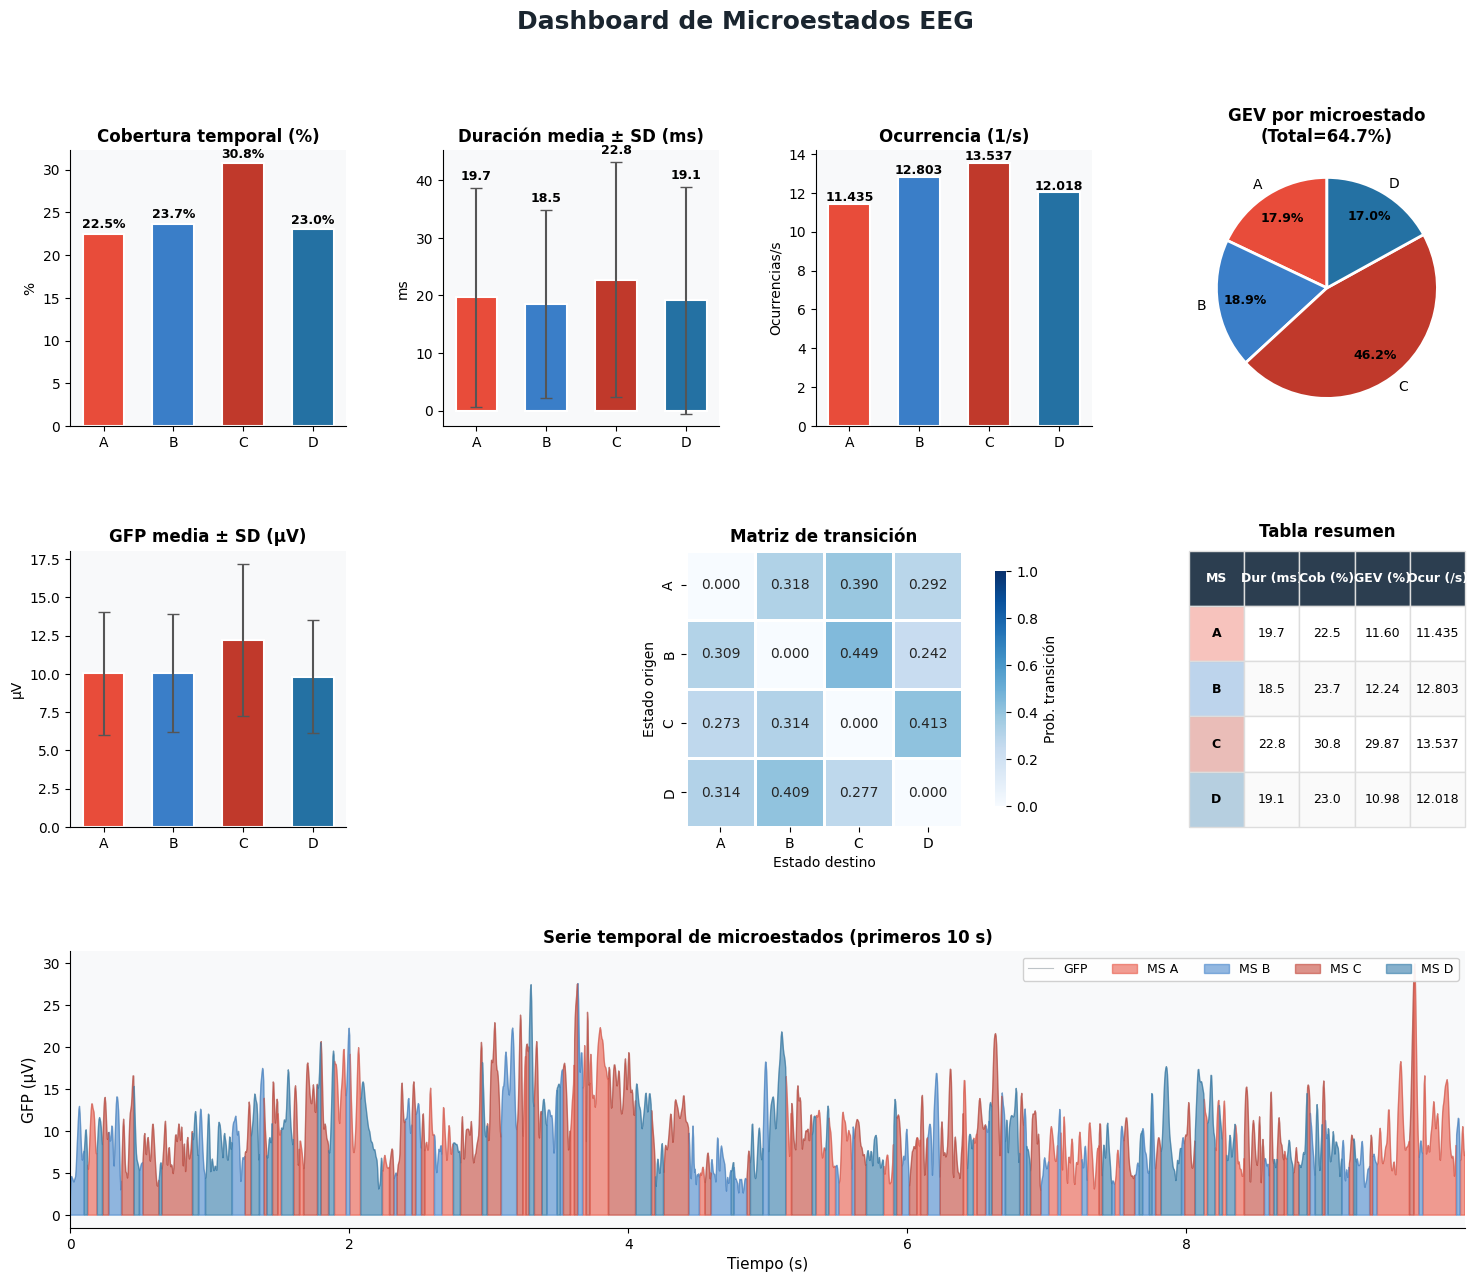

✅ Dashboard guardado: microstate_dashboard.png


In [ ]:
# ============================================================
# CELDA 11 — Dashboard publicable de variables por microestado
# ============================================================

def plot_microstate_dashboard(stats_df: pd.DataFrame,
                               trans_matrix: np.ndarray,
                               gfp: np.ndarray,
                               labels: np.ndarray,
                               times: np.ndarray,
                               n_states: int,
                               save_path: str = 'microstate_dashboard.png'):
    """
    Dashboard completo con las variables más representativas de microestados.
    """
    letters = list('ABCDEFG'[:n_states])
    colors = [MICROSTATE_COLORS.get(l, '#333') for l in letters]

    fig = plt.figure(figsize=(18, 14), facecolor='white')
    gs = gridspec.GridSpec(3, 4, figure=fig,
                           hspace=0.45, wspace=0.35)

    fig.suptitle('Dashboard de Microestados EEG',
                 fontsize=18, fontweight='bold',
                 color='#1A252F', y=0.98)

    # ── Panel 1: Cobertura (%) ──────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    vals = stats_df['Cobertura_%'].values
    bars = ax1.bar(letters, vals, color=colors, edgecolor='white',
                   linewidth=1.5, width=0.6)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9,
                 fontweight='bold')
    ax1.set_title('Cobertura temporal (%)', fontweight='bold')
    ax1.set_ylabel('%')
    ax1.spines[['top', 'right']].set_visible(False)
    ax1.set_facecolor('#F8F9FA')

    # ── Panel 2: Duración media (ms) ───────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    vals2 = stats_df['Duración_media_ms'].values
    errs2 = stats_df['Duración_std_ms'].values
    ax2.bar(letters, vals2, color=colors, edgecolor='white',
            linewidth=1.5, width=0.6, yerr=errs2, capsize=4,
            error_kw={'elinewidth': 1.5, 'ecolor': '#555'})
    for i, (val, err) in enumerate(zip(vals2, errs2)):
        ax2.text(i, val + err + 1,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9,
                 fontweight='bold')
    ax2.set_title('Duración media ± SD (ms)', fontweight='bold')
    ax2.set_ylabel('ms')
    ax2.spines[['top', 'right']].set_visible(False)
    ax2.set_facecolor('#F8F9FA')

    # ── Panel 3: Ocurrencia (1/s) ──────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    vals3 = stats_df['Ocurrencia_1/s'].values
    ax3.bar(letters, vals3, color=colors, edgecolor='white',
            linewidth=1.5, width=0.6)
    for i, val in enumerate(vals3):
        ax3.text(i, val + 0.002, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax3.set_title('Ocurrencia (1/s)', fontweight='bold')
    ax3.set_ylabel('Ocurrencias/s')
    ax3.spines[['top', 'right']].set_visible(False)
    ax3.set_facecolor('#F8F9FA')

    # ── Panel 4: GEV (%) ───────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[0, 3])
    vals4 = stats_df['GEV_%'].values
    wedges, texts, autotexts = ax4.pie(
        vals4, labels=letters, colors=colors,
        autopct='%1.1f%%', startangle=90,
        pctdistance=0.75, labeldistance=1.1,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for t in autotexts:
        t.set_fontsize(9)
        t.set_fontweight('bold')
    ax4.set_title(f'GEV por microestado\n(Total={vals4.sum():.1f}%)',
                  fontweight='bold')

    # ── Panel 5: GFP medio (µV) ───────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 0])
    vals5 = stats_df['GFP_media_µV'].values
    errs5 = stats_df['GFP_std_µV'].values
    ax5.bar(letters, vals5, color=colors, edgecolor='white',
            linewidth=1.5, width=0.6, yerr=errs5, capsize=4,
            error_kw={'elinewidth': 1.5, 'ecolor': '#555'})
    ax5.set_title('GFP media ± SD (µV)', fontweight='bold')
    ax5.set_ylabel('µV')
    ax5.spines[['top', 'right']].set_visible(False)
    ax5.set_facecolor('#F8F9FA')

    # ── Panel 6: Matriz de transición ─────────────────────────────────
    ax6 = fig.add_subplot(gs[1, 1:3])
    sns.heatmap(
        pd.DataFrame(trans_matrix, index=letters, columns=letters),
        ax=ax6, cmap='Blues', vmin=0, vmax=1,
        annot=True, fmt='.3f', linewidths=0.8,
        linecolor='white', square=True,
        cbar_kws={'shrink': 0.85, 'label': 'Prob. transición'}
    )
    ax6.set_title('Matriz de transición', fontweight='bold', fontsize=12)
    ax6.set_xlabel('Estado destino')
    ax6.set_ylabel('Estado origen')

    # ── Panel 7: Tabla resumen ─────────────────────────────────────────
    ax7 = fig.add_subplot(gs[1, 3])
    ax7.axis('off')
    summary_data = []
    col_labels = ['MS', 'Dur (ms)', 'Cob (%)', 'GEV (%)','Ocur (/s)']
    for letter in letters:
        row = stats_df.loc[letter]
        summary_data.append([
            letter,
            f"{row['Duración_media_ms']:.1f}",
            f"{row['Cobertura_%']:.1f}",
            f"{row['GEV_%']:.2f}",
            f"{row['Ocurrencia_1/s']:.3f}",
        ])

    table = ax7.table(
        cellText=summary_data,
        colLabels=col_labels,
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    for (r, c), cell in table.get_celld().items():
        if r == 0:
            cell.set_facecolor('#2C3E50')
            cell.set_text_props(color='white', fontweight='bold')
        elif r > 0 and c == 0:
            letter = letters[r-1]
            cell.set_facecolor(MICROSTATE_COLORS.get(letter, '#EEE') + '55')
            cell.set_text_props(fontweight='bold')
        else:
            cell.set_facecolor('#FAFAFA' if r % 2 == 0 else 'white')
        cell.set_edgecolor('#DDD')

    ax7.set_title('Tabla resumen', fontweight='bold', pad=10)

    # ── Panel 8: Serie temporal de microestados (segmento) ────────────
    ax8 = fig.add_subplot(gs[2, :])

    # Mostrar solo los primeros 10 segundos
    n_show = min(int(10 * sfreq), len(labels))
    t_show = times[:n_show]
    gfp_show = gfp[:n_show] * 1e6
    labels_show = labels[:n_show]

    # GFP
    ax8.plot(t_show, gfp_show, color='#BDC3C7', linewidth=0.8,
             zorder=1, label='GFP')

    # Colorear por microestado
    for k in range(n_states):
        mask_k = labels_show == k
        ax8.fill_between(t_show, 0, gfp_show,
                          where=mask_k,
                          color=MICROSTATE_COLORS.get(letters[k], '#333'),
                          alpha=0.55, label=f'MS {letters[k]}',
                          zorder=2)

    ax8.set_xlabel('Tiempo (s)', fontsize=11)
    ax8.set_ylabel('GFP (µV)', fontsize=11)
    ax8.set_title('Serie temporal de microestados (primeros 10 s)',
                  fontweight='bold')
    ax8.legend(ncol=n_states + 1, fontsize=9, loc='upper right',
               framealpha=0.9)
    ax8.spines[['top', 'right']].set_visible(False)
    ax8.set_facecolor('#F8F9FA')
    ax8.set_xlim(t_show[0], t_show[-1])

    plt.savefig(save_path, dpi=200, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()
    print(f'✅ Dashboard guardado: {save_path}')


plot_microstate_dashboard(
    stats_df=stats_df,
    trans_matrix=trans_matrix,
    gfp=gfp,
    labels=labels_all,
    times=times,
    n_states=N_MICROSTATES,
    save_path='microstate_dashboard.png'
)

## 📤 12. Exportación de Resultados

In [ ]:
# ============================================================
# CELDA 12 — Exportación completa de resultados
# ============================================================
import zipfile
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_dir = Path(f'microstate_results_{timestamp}')
output_dir.mkdir(exist_ok=True)

# 1. Estadísticas por microestado
stats_path = output_dir / 'microstate_statistics.csv'
stats_df.to_csv(stats_path)
print(f'✅ Estadísticas exportadas: {stats_path}')

# 2. Matriz de transición
trans_df_out = pd.DataFrame(trans_matrix,
                             index=list('ABCDEFG'[:N_MICROSTATES]),
                             columns=list('ABCDEFG'[:N_MICROSTATES]))
trans_path = output_dir / 'transition_matrix.csv'
trans_df_out.to_csv(trans_path)
print(f'✅ Matriz de transición exportada: {trans_path}')

# 3. Mapas de microestados (valores por canal)
centers_df = pd.DataFrame(
    modkmeans.cluster_centers_,
    index=raw_preprocessed.ch_names,
    columns=list('ABCDEFG'[:N_MICROSTATES])
)
centers_path = output_dir / 'microstate_maps.csv'
centers_df.to_csv(centers_path)
print(f'✅ Mapas topográficos exportados: {centers_path}')

# 4. Etiquetas temporales
labels_df = pd.DataFrame({
    'time_s':    times,
    'label_num': labels_all,
    'label_let': [list('ABCDEFG'[:N_MICROSTATES])[l] for l in labels_all],
    'gfp_uV':    gfp * 1e6
})
labels_path = output_dir / 'labels_timeseries.csv'
labels_df.to_csv(labels_path, index=False)
print(f'✅ Series temporales exportadas: {labels_path}')

# 5. Copiar figuras al directorio de resultados
import shutil
for fig_name in ['microstates_topomaps.png', 'microstate_dashboard.png',
                  'transition_matrices.png', 'gfp_trace.png', 'optimal_k_curve.png']:
    if os.path.exists(fig_name):
        shutil.copy(fig_name, output_dir / fig_name)

# 6. Comprimir todo en un ZIP
zip_path = f'microstate_results_{timestamp}.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for file in output_dir.rglob('*'):
        zf.write(file, file.relative_to(output_dir.parent))

print(f'\n📦 Resultados empaquetados: {zip_path}')

# Descarga automática en Colab
try:
    from google.colab import files
    files.download(zip_path)
    print('⬇️  Descarga iniciada en el navegador')
except ImportError:
    print(f'ℹ️  Archivo listo para descarga manual: {zip_path}')

✅ Estadísticas exportadas: microstate_results_20260323_224658/microstate_statistics.csv
✅ Matriz de transición exportada: microstate_results_20260323_224658/transition_matrix.csv
✅ Mapas topográficos exportados: microstate_results_20260323_224658/microstate_maps.csv
✅ Series temporales exportadas: microstate_results_20260323_224658/labels_timeseries.csv

📦 Resultados empaquetados: microstate_results_20260323_224658.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Descarga iniciada en el navegador


## 🧪 13. Análisis Estadístico (Comparación entre Grupos)

In [ ]:
# ============================================================
# CELDA 13 — Template de comparación entre grupos
# ============================================================
# Este módulo permite comparar variables de microestados entre grupos
# (ej. controles vs. pacientes, condición A vs. B)

def compare_groups(group1_stats: pd.DataFrame,
                   group2_stats: pd.DataFrame,
                   group_names: tuple = ('Grupo 1', 'Grupo 2'),
                   variables: list = None):
    """
    Realiza comparación entre dos grupos con Mann-Whitney U test
    (no paramétrico, recomendado para métricas de microestados).

    Parameters
    ----------
    group1_stats, group2_stats : DataFrames con una fila por sujeto
                                 y columnas = variables de microestados
    """
    from scipy.stats import mannwhitneyu

    if variables is None:
        variables = group1_stats.columns.tolist()

    results = []
    for var in variables:
        if var not in group1_stats.columns:
            continue
        u_stat, p_val = mannwhitneyu(
            group1_stats[var].dropna(),
            group2_stats[var].dropna(),
            alternative='two-sided'
        )
        r_effect = 1 - (2 * u_stat) / (len(group1_stats) * len(group2_stats))
        results.append({
            'Variable': var,
            f'Media {group_names[0]}': group1_stats[var].mean(),
            f'Media {group_names[1]}': group2_stats[var].mean(),
            'U estadístico': u_stat,
            'p-valor': p_val,
            'p FDR': None,  # rellenar con statsmodels.stats.multitest
            'r efecto': r_effect,
            'Significativo': '***' if p_val < 0.001 else ('**' if p_val < 0.01
                              else ('*' if p_val < 0.05 else 'ns'))
        })

    return pd.DataFrame(results)


print('ℹ️  Template de comparación entre grupos cargado.')
print('   Para usarlo:')
print('   compare_groups(df_group1, df_group2, group_names=("Control", "Paciente"))')
print()
print('   Donde df_group1 y df_group2 son DataFrames con una fila por sujeto')
print('   y columnas = variables de microestados (duración, cobertura, GEV, etc.)')

ℹ️  Template de comparación entre grupos cargado.
   Para usarlo:
   compare_groups(df_group1, df_group2, group_names=("Control", "Paciente"))

   Donde df_group1 y df_group2 son DataFrames con una fila por sujeto
   y columnas = variables de microestados (duración, cobertura, GEV, etc.)


## 📋 14. Resumen Final del Pipeline

In [ ]:
# ============================================================
# CELDA 14 — Resumen final
# ============================================================

print('=' * 65)
print('  🧠  RESUMEN — ANÁLISIS DE MICROESTADOS EEG')
print('=' * 65)
print(f'  Canales EEG:         {len(raw_preprocessed.ch_names)}')
print(f'  Frecuencia muestreo: {sfreq:.0f} Hz')
print(f'  Duración total:      {times[-1]:.1f} s')
print(f'  Frames totales:      {len(labels_all):,}')
print(f'  Picos GFP usados:    {gfp_peak_maps.shape[1]:,}')
print(f'  Número microestados: {N_MICROSTATES} (A–{chr(64+N_MICROSTATES)})')
print()
print('  VARIABLES POR MICROESTADO:')
print('-' * 65)
print(stats_df.to_string())
print()
print('  GEV TOTAL:', f"{modkmeans.gev_.sum()*100:.2f}%")
print('=' * 65)
print()
print('  ARCHIVOS GENERADOS:')
for fname in ['microstates_topomaps.png', 'microstate_dashboard.png',
              'transition_matrices.png', 'gfp_trace.png',
              'optimal_k_curve.png', zip_path]:
    if os.path.exists(fname):
        size = os.path.getsize(fname) / 1024
        print(f'  ✅ {fname:<40} ({size:.1f} KB)')
print()
print('  REFERENCIAS:')
print('  [1] Lehmann et al. (1987) EEG alpha map series. Electroencephalogr Clin Neurophysiol')
print('  [2] Pascual-Marqui et al. (1995) Segmentation of brain electrical activity.')
print('  [3] Murray et al. (2008) EEG microstates: a new approach. J Neurophysiol')
print('  [4] Poulsen et al. (2018) Microstate EEGlab toolbox. Front Neurosci')
print('  [5] Lehmann & Skrandies (1980) Global field power. Electroencephalogr Clin')
print('=' * 65)

  🧠  RESUMEN — ANÁLISIS DE MICROESTADOS EEG
  Canales EEG:         32
  Frecuencia muestreo: 250 Hz
  Duración total:      238.3 s
  Frames totales:      59,578
  Picos GFP usados:    6,313
  Número microestados: 4 (A–D)

  VARIABLES POR MICROESTADO:
-----------------------------------------------------------------
             Duración_media_ms  Duración_std_ms  Cobertura_%  Ocurrencia_1/s  N_ocurrencias    GEV_%  GFP_media_µV  GFP_std_µV
Microestado                                                                                                                   
A                        19.68            18.99        22.51         11.4346           2725  11.5972       10.0514      4.0158
B                        18.51            16.26        23.69         12.8025           3051  12.2394       10.0751      3.8407
C                        22.75            20.39        30.79         13.5369           3226  29.8651       12.2303      4.9751
D                        19.14            19.67 